# Mapa de demandas territoriales con relación ALTA a GRD

Construye el mapa coroplético de Colombia por departamento a partir de la hoja `Demandas-Territoriales-2022-24` del libro "Estrategia CyT GRD" (columnas B y H). Se referencia como figura desde `article.md`.

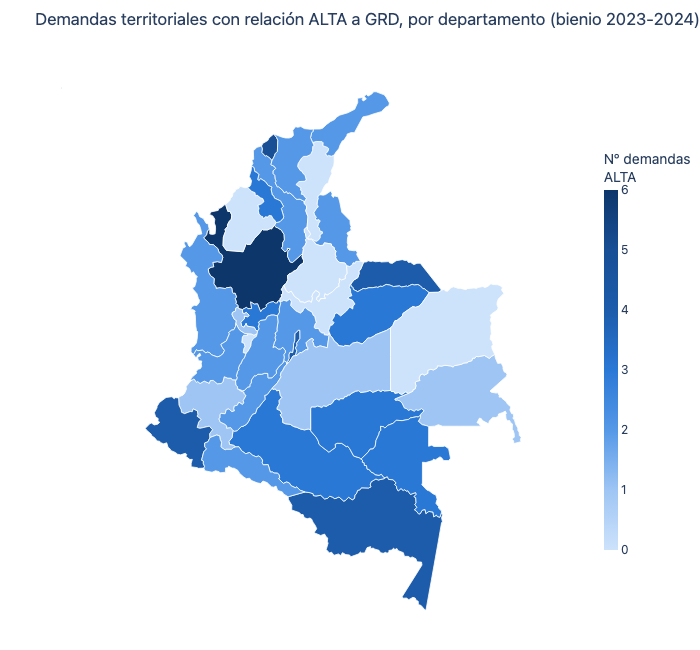

In [1]:
#| label: cell-demandas-mapa
import json
import urllib.request

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Demandas-Territoriales-2022-24"
GEOJSON_URL = "https://raw.githubusercontent.com/caticoa3/colombia_mapa/master/co_2018_MGN_DPTO_POLITICO.geojson"

df = pd.read_csv(CSV_URL)
with urllib.request.urlopen(GEOJSON_URL) as resp:
    geo = json.load(resp)

# The DEPARTAMENTO cell for San Andrés is truncated at the source; reconstruct it.
NAME_FIX = {"r\u00e9s, Providencia y Santa": "San Andr\u00e9s, Providencia y Santa Catalina"}
df["departamento"] = df["DEPARTAMENTO"].str.strip().replace(NAME_FIX)
df["relacion"] = df["RELACION CON GRD (ALTA, MEDIA, BAJA)"].str.strip().str.upper()
alta = df[df["relacion"].isin(["ALTA", "ALTO"])]

counts = alta.groupby("departamento").size()
retos = alta.groupby("departamento")["RETO"].apply(lambda s: list(dict.fromkeys(s))[:3])

# Map the geojson's official DIVIPOLA names onto the sheet's department spelling.
NAME_MAP = {
    "AMAZONAS": "Amazonas", "ANTIOQUIA": "Antioquia", "ARAUCA": "Arauca",
    "ARCHIPI\u00c9LAGO DE SAN ANDR\u00c9S, PROVIDENCIA Y SANTA CATALINA": "San Andr\u00e9s, Providencia y Santa Catalina",
    "ATL\u00c1NTICO": "Atl\u00e1ntico", "BOGOT\u00c1, D.C.": "Bogot\u00e1 D.C.", "BOL\u00cdVAR": "Bol\u00edvar", "BOYAC\u00c1": "Boyac\u00e1",
    "CALDAS": "Caldas", "CAQUET\u00c1": "Caquet\u00e1", "CASANARE": "Casanare", "CAUCA": "Cauca", "CESAR": "Cesar",
    "CHOC\u00d3": "Choc\u00f3", "CUNDINAMARCA": "Cundinamarca", "C\u00d3RDOBA": "C\u00f3rdoba", "GUAIN\u00cdA": "Guain\u00eda",
    "GUAVIARE": "Guaviare", "HUILA": "Huila", "LA GUAJIRA": "La Guajira", "MAGDALENA": "Magdalena",
    "META": "Meta", "NARI\u00d1O": "Nari\u00f1o", "NORTE DE SANTANDER": "Norte de Santander", "PUTUMAYO": "Putumayo",
    "QUINDIO": "Quind\u00edo", "RISARALDA": "Risaralda", "SANTANDER": "Santander", "SUCRE": "Sucre",
    "TOLIMA": "Tolima", "VALLE DEL CAUCA": "Valle del Cauca", "VAUP\u00c9S": "Vaup\u00e9s", "VICHADA": "Vichada",
}
for f in geo["features"]:
    f["properties"]["name"] = NAME_MAP[f["properties"]["DPTO_CNMBR"]]

all_names = sorted(NAME_MAP.values())
count_list = [int(counts.get(n, 0)) for n in all_names]
hover_retos = [
    "<br>".join(f"&#8226; {r[:70]}" for r in retos.get(n, [])) or "Sin demandas ALTA registradas"
    for n in all_names
]

max_count = max(count_list)
# Sequential blue ramp (dataviz skill palette, steps 100->700)
SEQ = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#184f95", "#0d366b"]
colorscale = [[i / (len(SEQ) - 1), c] for i, c in enumerate(SEQ)]

fig = go.Figure(go.Choropleth(
    geojson=geo,
    featureidkey="properties.name",
    locations=all_names,
    z=count_list,
    zmin=0, zmax=max_count,
    colorscale=colorscale,
    marker_line_color="white",
    marker_line_width=0.8,
    customdata=hover_retos,
    hovertemplate="<b>%{location}</b><br>%{z} demanda(s) ALTA<br>%{customdata}<extra></extra>",
    colorbar=dict(title="N\u00ba demandas<br>ALTA", thickness=14, len=0.7),
))
fig.update_geos(fitbounds="locations", visible=False, projection_type="mercator")
fig.update_layout(
    title="Demandas territoriales con relaci\u00f3n ALTA a GRD, por departamento (bienio 2023-2024)",
    margin=dict(l=0, r=0, t=50, b=0),
    height=650,
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
)
fig.show()


## Mapa de demandas territoriales 2025-2026

Misma fuente y variables (columnas B y H), hoja `Demandas-Territoriales-2025-26`.

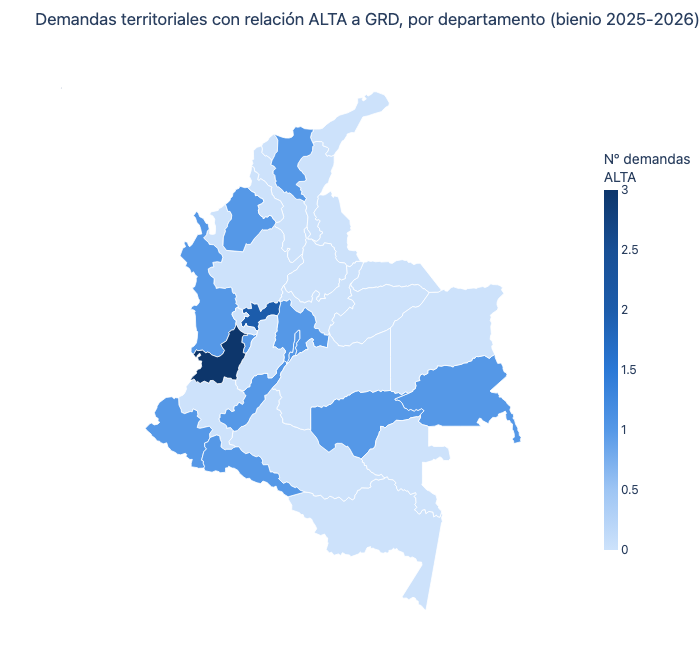

In [2]:
#| label: cell-demandas-mapa-2025-26
import json
import urllib.request

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+png"

SHEET_ID = "1x83kWcmNX5OJ1-aP36_liBzp7iJOz228xAkrAb5-RkE"
CSV_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&sheet=Demandas-Territoriales-2025-26"
GEOJSON_URL = "https://raw.githubusercontent.com/caticoa3/colombia_mapa/master/co_2018_MGN_DPTO_POLITICO.geojson"

df = pd.read_csv(CSV_URL)
with urllib.request.urlopen(GEOJSON_URL) as resp:
    geo = json.load(resp)

# This sheet spells the capital district "Bogot\u00e1"; align it with the geojson's "Bogot\u00e1 D.C.".
NAME_FIX = {"Bogot\u00e1": "Bogot\u00e1 D.C."}
df["departamento"] = df["DEPARTAMENTO"].str.strip().replace(NAME_FIX)
df["relacion"] = df["RELACION CON GRD (ALTA, MEDIA, BAJA)"].astype(str).str.strip().str.upper()
alta = df[df["relacion"].isin(["ALTA", "ALTO"])]

counts = alta.groupby("departamento").size()
retos = alta.groupby("departamento")["RETO"].apply(lambda s: list(dict.fromkeys(s))[:3])

# Map the geojson's official DIVIPOLA names onto the sheet's department spelling.
NAME_MAP = {
    "AMAZONAS": "Amazonas", "ANTIOQUIA": "Antioquia", "ARAUCA": "Arauca",
    "ARCHIPI\u00c9LAGO DE SAN ANDR\u00c9S, PROVIDENCIA Y SANTA CATALINA": "San Andr\u00e9s, Providencia y Santa Catalina",
    "ATL\u00c1NTICO": "Atl\u00e1ntico", "BOGOT\u00c1, D.C.": "Bogot\u00e1 D.C.", "BOL\u00cdVAR": "Bol\u00edvar", "BOYAC\u00c1": "Boyac\u00e1",
    "CALDAS": "Caldas", "CAQUET\u00c1": "Caquet\u00e1", "CASANARE": "Casanare", "CAUCA": "Cauca", "CESAR": "Cesar",
    "CHOC\u00d3": "Choc\u00f3", "CUNDINAMARCA": "Cundinamarca", "C\u00d3RDOBA": "C\u00f3rdoba", "GUAIN\u00cdA": "Guain\u00eda",
    "GUAVIARE": "Guaviare", "HUILA": "Huila", "LA GUAJIRA": "La Guajira", "MAGDALENA": "Magdalena",
    "META": "Meta", "NARI\u00d1O": "Nari\u00f1o", "NORTE DE SANTANDER": "Norte de Santander", "PUTUMAYO": "Putumayo",
    "QUINDIO": "Quind\u00edo", "RISARALDA": "Risaralda", "SANTANDER": "Santander", "SUCRE": "Sucre",
    "TOLIMA": "Tolima", "VALLE DEL CAUCA": "Valle del Cauca", "VAUP\u00c9S": "Vaup\u00e9s", "VICHADA": "Vichada",
}
for f in geo["features"]:
    f["properties"]["name"] = NAME_MAP[f["properties"]["DPTO_CNMBR"]]

all_names = sorted(NAME_MAP.values())
count_list = [int(counts.get(n, 0)) for n in all_names]
hover_retos = [
    "<br>".join(f"&#8226; {r[:70]}" for r in retos.get(n, [])) or "Sin demandas ALTA registradas"
    for n in all_names
]

max_count = max(count_list)
# Sequential blue ramp (dataviz skill palette, steps 100->700)
SEQ = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#1c5cab", "#184f95", "#0d366b"]
colorscale = [[i / (len(SEQ) - 1), c] for i, c in enumerate(SEQ)]

fig = go.Figure(go.Choropleth(
    geojson=geo,
    featureidkey="properties.name",
    locations=all_names,
    z=count_list,
    zmin=0, zmax=max_count,
    colorscale=colorscale,
    marker_line_color="white",
    marker_line_width=0.8,
    customdata=hover_retos,
    hovertemplate="<b>%{location}</b><br>%{z} demanda(s) ALTA<br>%{customdata}<extra></extra>",
    colorbar=dict(title="N\u00ba demandas<br>ALTA", thickness=14, len=0.7),
))
fig.update_geos(fitbounds="locations", visible=False, projection_type="mercator")
fig.update_layout(
    title="Demandas territoriales con relaci\u00f3n ALTA a GRD, por departamento (bienio 2025-2026)",
    margin=dict(l=0, r=0, t=50, b=0),
    height=650,
    font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif"),
)
fig.show()
